## 0. Imports

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, randint

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (StratifiedGroupKFold, RandomizedSearchCV,
                                     cross_val_predict)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             confusion_matrix, classification_report)

warnings.filterwarnings('ignore')
try:
    import koreanize_matplotlib  # noqa: F401  (한글 폰트; 없으면 무시)
except Exception:
    pass



## 1. Config

`DATA_DIR`: 원본 CSV가 있는 폴더.

In [ ]:
DATA_DIR     = os.environ.get('DATA_DIR', './data')
WEIGHTS_PATH = os.environ.get('WEIGHTS_PATH', './data/station_catchment_weights.csv')
ARTIFACT_DIR = './artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

RANDOM_STATE = 42
N_CLASSES    = 4
OUTER_SPLITS = 5       # nested CV 바깥 폴드 수 (성능 추정)
INNER_SPLITS = 3       # nested CV 안쪽 폴드 수 (하이퍼파라미터 탐색)
WEEKDAY_ONLY = True
CATCHMENT_R  = 250     # make_catchment_weights.py 에서 사용한 버퍼 반경(m), 기록용
MIN_STATIONS_PER_LINE = 5

FAST   = False         # True로 바꾸면 모델당 8회 반복 (빠른 동작 확인용)
N_ITER = {'LogReg': 20, 'RandomForest': 40, 'LightGBM': 50}
if FAST:
    N_ITER = {k: 8 for k in N_ITER}

dir_map    = {'외선': 0, '내선': 1, '상선': 0, '하선': 1}
ratio_cols = ['주거_ratio', '직장_ratio', '관광_ratio']
FEATURES   = ['상하구분', '시간대'] + ratio_cols   # 역번호·행정동 코드 등 식별자 제외
np.random.seed(RANDOM_STATE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. 데이터 로드

In [ ]:
def _dong_mean(fname, col):
    d = pd.read_csv(os.path.join(DATA_DIR, fname), encoding='cp949')
    d = d[d['기준_년분기_코드'] >= 20251]
    return d.groupby('행정동_코드_명')[col].mean()

# 파일명은 열린데이터광장 원본 기준; 재다운로드 시 변경 필요
resi_g = _dong_mean('서울시 상권분석서비스(상주인구-행정동_주거).csv', '완루인_총_상주인구_수')
work_g = _dong_mean('서울시 상권분석서비스(직장인구-행정동_직장).csv', '완루인_전장_직장_인구_수')
road_g = _dong_mean('서울시 상권분석서비스(길단위인구-행정동_관광).csv', '완루인_유동인구_수')
pop = pd.DataFrame({'주거': resi_g, '직장': work_g, '관광': road_g})


def _load_congestion():
    # 분기별 파일을 개별 로드 후 합침; 호선 인코딩 통일은 아래에서 처리
    specs = [
        ('서울교통공사_지하철혼잡도정보1_20250331.csv',       '2025Q1'),
        ('서울교통공사_지하철혼잡도정보_20250630_2분기.csv',  '2025Q2'),
        ('서울교통공사_지하철혼잡도정보_20250930_3분기.csv',  '2025Q3'),
        ('서울교통공사_지하철혼잡도정보_20251130_4분기.csv',  '2025Q4'),
    ]
    parts = []
    for fname, q in specs:
        d = pd.read_csv(os.path.join(DATA_DIR, fname), encoding='cp949')
        d['분기'] = q
        parts.append(d)
    return pd.concat(parts, ignore_index=True)

df_cong = _load_congestion()
df_cong['출발역'] = df_cong['출발역'].replace('신춘(지하)', '신춘')

# Q1은 호선을 정수(2)로, Q2~Q4는 문자열('2호선')로 저장 — 통일하지 않으면 그룹 누수 발생
def _norm_line(v):
    digits = ''.join(ch for ch in str(v) if ch.isdigit())
    return f'{int(digits)}호선' if digits else str(v)
df_cong['호선'] = df_cong['호선'].map(_norm_line)

W = pd.read_csv(WEIGHTS_PATH)   # 콜럼: 역명, 동, weight
print(f'[load] dongs={len(pop)} | lines={df_cong["호선"].nunique()} | weighted stations={W["역명"].nunique()}')

[load] dongs=424 | lines=8 | weighted stations=224


## 3. 피처 엔지니어링 — 역세권 토지이용 비율

역 반경 250m 내 행정동 인구를 면적가중 합산한 뒤 주거/직장/관광 비율로 변환.
-> 단일 행정동 할당 방식과 달리 경계에 겹쳐진 역의 오배정 문제를 제거할 수 있다.

In [ ]:
# 역별 가중치 재정규화 (인구 없는 동 제외 후)
Wm = W.merge(pop, left_on='동', right_index=True, how='left')
Wm = Wm.dropna(subset=['주거', '직장', '관광']).copy()
Wm['w'] = Wm['weight'] / Wm.groupby('역명')['weight'].transform('sum')
for c in ['주거', '직장', '관광']:
    Wm[c + '_wp'] = Wm['w'] * Wm[c]
sta = Wm.groupby('역명')[['주거_wp', '직장_wp', '관광_wp']].sum()
sta.columns = ['주거', '직장', '관광']

# 전역 min-max 후 합=1 정규화 → 노선 간 비교 가능한 비율로 변환
for raw, n in [('주거', '주거_n'), ('직장', '직장_n'), ('관광', '관광_n')]:
    lo, hi = sta[raw].min(), sta[raw].max()
    sta[n] = (sta[raw] - lo) / (hi - lo)
tot = sta[['주거_n', '직장_n', '관광_n']].sum(axis=1)
for r, n in [('주거_ratio', '주거_n'), ('직장_ratio', '직장_n'), ('관광_ratio', '관광_n')]:
    sta[r] = sta[n] / tot
assert np.allclose(sta[ratio_cols].sum(axis=1), 1.0)
sta = sta[ratio_cols].reset_index()

sta.head()

## 4. 피처 엔지니어링 — 혼잡도 롱 테이블 + 타겟

In [ ]:
def _build_long(c):
    if WEEKDAY_ONLY:
        c = c[c['요일구분'] == '평일']
    c = c.copy()
    c['상하구분'] = c['상하구분'].map(dir_map)
    c = c[c['상하구분'].notna()]
    tcols = [x for x in c.columns if ('시' in x and '분' in x)]
    hour_of = {x: int(x.split('시')[0]) for x in tcols}   # '6시30분' → 6, '00시00분' → 0
    agg = c.groupby(['호선', '출발역', '상하구분'])[tcols].mean().reset_index()
    for h in sorted(set(hour_of.values())):                # 30분 단위 → 1시간 통합(평균)
        agg[h if h else 24] = agg[[x for x in tcols if hour_of[x] == h]].mean(axis=1)
    hours = [h if h else 24 for h in sorted(set(hour_of.values()))]
    lg = agg.melt(['호선', '출발역', '상하구분'], hours, '시간대', '혼잡도')
    lg['시간대'] = lg['시간대'].astype(int)
    return lg

long = _build_long(df_cong)
df = long.merge(sta, left_on='출발역', right_on='역명', how='left').drop(columns='역명')
df = df.dropna(subset=ratio_cols).copy()

cov = df.groupby('호선')['출발역'].nunique().sort_values(ascending=False)
LINES = cov[cov >= MIN_STATIONS_PER_LINE].index.tolist()
df = df[df['호선'].isin(LINES)].copy()
df['gid'] = df['호선'].astype(str) + '_' + df['출발역']   # CV 그룹 단위 = 노선별 역
df['혼잡도_등급'] = pd.qcut(df['혼잡도'], q=N_CLASSES, labels=False, duplicates='drop').astype(int)

X = df[FEATURES].reset_index(drop=True)
y = df['혼잡도_등급'].reset_index(drop=True)
groups = df['gid'].reset_index(drop=True)
print(f'[features] rows={len(df)} lines={df["호선"].nunique()} stations={groups.nunique()} '
      f'target={y.value_counts().sort_index().to_dict()}')

[features] rows=10060 lines=8 stations=254 target={0: 2517, 1: 2516, 2: 2513, 3: 2514}


## 5. CV 설정

`StratifiedGroupKFold`로 같은 역이 train/test에 동시에 들어가지 않도록 데이터 누수 차단.

In [ ]:
outer_cv = list(StratifiedGroupKFold(OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
                .split(X, y, groups=groups))
for k, (tr, te) in enumerate(outer_cv):
    assert not (set(groups.iloc[tr]) & set(groups.iloc[te])), f'fold {k} group leak'
print('그룹 누수 없음 ✓')


def nested_cv(estimator, space, n_iter, X, y, groups, outer):
    """바깥 폴드로 성능 추정, 안쪽 폴드로 하이퍼파라미터 탐색 - 선택 편향 없는 honest 추정."""
    oof = pd.Series(index=y.index, dtype=float)
    picks = []
    for tr, te in outer:
        Xtr = X.iloc[tr].reset_index(drop=True)
        ytr = y.iloc[tr].reset_index(drop=True)
        gtr = groups.iloc[tr].reset_index(drop=True)
        inner = list(StratifiedGroupKFold(INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
                     .split(Xtr, ytr, groups=gtr))
        search = RandomizedSearchCV(estimator, space, n_iter=n_iter, scoring='f1_macro',
                                    cv=inner, random_state=RANDOM_STATE, n_jobs=-1, refit=True)
        search.fit(Xtr, ytr)
        oof.iloc[te] = search.best_estimator_.predict(X.iloc[te])
        picks.append(search.best_params_)
    return oof.astype(int), picks


def full_search(estimator, space, n_iter, X, y, outer):
    """전체 데이터로 최종 모델/파라미터 산출 (해석·저장용). 성능 보고는 nested 값 사용."""
    s = RandomizedSearchCV(estimator, space, n_iter=n_iter, scoring='f1_macro',
                           cv=outer, random_state=RANDOM_STATE, n_jobs=-1, refit=True)
    s.fit(X, y)
    return s.best_estimator_, s.best_params_

,상하구분,시간대,주거_ratio,직장_ratio,관광_ratio
0,0,24,0.294039,0.020790,0.685170
1,1,24,0.294039,0.020790,0.685170
2,0,24,0.344699,0.019770,0.635531
3,1,24,0.344699,0.019770,0.635531
4,0,24,0.000000,0.785472,0.214528
...,...,...,...,...,...
10055,1,23,0.543337,0.305532,0.151131
10056,0,23,0.555985,0.167238,0.276777
10057,1,23,0.555985,0.167238,0.276777
10058,0,23,0.498849,0.008917,0.492234


## 6. 모델 정의

In [ ]:
MODELS = {
    'LogReg': (
        Pipeline([('scaler', MinMaxScaler()),
                  ('clf', LogisticRegression(class_weight='balanced', solver='saga',
                                             max_iter=5000, random_state=RANDOM_STATE))]),
        {'clf__C': loguniform(1e-3, 1e2),
         'clf__penalty': ['l1', 'l2'],
         'clf__l1_ratio': [None]},
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': randint(200, 700),
         'max_depth': [4, 6, 8, 12, None],
         'min_samples_leaf': randint(1, 12),
         'min_samples_split': randint(2, 12),
         'max_features': ['sqrt', 'log2', None]},
    ),
    'LightGBM': (
        lgb.LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE,
                           verbose=-1, subsample_freq=1),
        {'num_leaves': randint(15, 150),
         'learning_rate': loguniform(0.01, 0.3),
         'n_estimators': randint(200, 900),
         'min_child_samples': randint(5, 80),
         'subsample': [0.7, 0.85, 1.0],
         'colsample_bytree': [0.7, 0.85, 1.0],
         'reg_alpha': [0.0, 0.1, 1.0],
         'reg_lambda': [0.0, 0.1, 1.0]},
    ),
}

## 7. Nested CV — Honest 튜닝 성능

선택 편향 없이 튜닝된 성능을 추정. (최종 보고 지표)

In [ ]:
results = {}
for name, (est, space) in MODELS.items():
    oof, picks = nested_cv(est, space, N_ITER[name], X, y, groups, outer_cv)
    results[name] = {
        'nested_macro_f1': float(f1_score(y, oof, average='macro')),
        'nested_accuracy': float(accuracy_score(y, oof)),
        'nested_mae':      float(mean_absolute_error(y, oof)),
        'fold_params':     picks,
    }
    print(f'  {name:14s} | nested MacroF1 {results[name]["nested_macro_f1"]:.3f} '
          f'| Acc {results[name]["nested_accuracy"]:.3f} | MAE {results[name]["nested_mae"]:.3f}')

best_name = max(results, key=lambda k: results[k]['nested_macro_f1'])
print(f'\n[select] 메인 모델 = {best_name}')

  LogReg         | nested MacroF1 0.271 | Acc 0.296 | MAE 1.134
  RandomForest   | nested MacroF1 0.450 | Acc 0.455 | MAE 0.811
  LightGBM       | nested MacroF1 0.446 | Acc 0.449 | MAE 0.815

[select] honest 기준 메인 모델 = RandomForest


## 8. 전체 데이터 최종 학습

In [ ]:
best_estimators, best_params = {}, {}
for name, (est, space) in MODELS.items():
    model, params = full_search(est, space, N_ITER[name], X, y, outer_cv)
    best_estimators[name] = model
    best_params[name] = {k: (float(v) if isinstance(v, (np.floating,)) else v)
                         for k, v in params.items()}
    print(f'  {name:14s} best params: {best_params[name]}')

main_model = best_estimators[best_name]

  LogReg         best params: {'clf__C': 0.0010090061869151559, 'clf__l1_ratio': None, 'clf__penalty': 'l2'}
  RandomForest   best params: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 4, 'n_estimators': 405}
  LightGBM       best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01471005003927122, 'min_child_samples': 27, 'n_estimators': 614, 'num_leaves': 56, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.85}


## 9. 평가

[eval:RandomForest] Acc 0.460 | MacroF1 0.457 | MAE 0.798 | 치명오차(0↔3) 6.32%

               precision    recall  f1-score   support

           0      0.537     0.536     0.536      2517
           1      0.367     0.367     0.367      2516
           2      0.426     0.355     0.387      2513
           3      0.497     0.582     0.536      2514

    accuracy                          0.460     10060
   macro avg      0.457     0.460     0.457     10060
weighted avg      0.457     0.460     0.457     10060



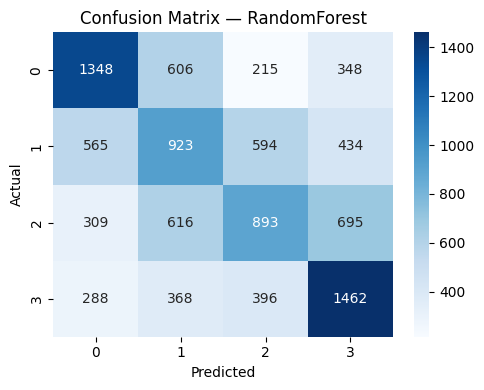

In [ ]:
y_oof = cross_val_predict(main_model, X, y, cv=outer_cv, n_jobs=-1)
eval_metrics = {
    'model':    best_name,
    'accuracy': float(accuracy_score(y, y_oof)),
    'macro_f1': float(f1_score(y, y_oof, average='macro')),
    'mae':      float(mean_absolute_error(y, y_oof)),
}
res = pd.DataFrame({'a': y.values, 'p': y_oof})
crit = ((res.a == N_CLASSES - 1) & (res.p == 0)) | ((res.a == 0) & (res.p == N_CLASSES - 1))
eval_metrics['critical_error_rate'] = float(crit.mean())
print(f'[eval:{best_name}] Acc {eval_metrics["accuracy"]:.3f} | MacroF1 {eval_metrics["macro_f1"]:.3f} '
      f'| MAE {eval_metrics["mae"]:.3f} | 치명오차(0⇔{N_CLASSES-1}) {eval_metrics["critical_error_rate"]*100:.2f}%')
print('\n', classification_report(y, y_oof, digits=3))

cm = confusion_matrix(y, y_oof)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout(); plt.savefig(f'{ARTIFACT_DIR}/confusion_matrix.png', dpi=150); plt.show()

## 10. 피처 중요도

[permutation importance]
 시간대         0.2186
상하구분        0.0310
직장_ratio    0.0220
주거_ratio    0.0080
관광_ratio   -0.0068

[impurity importance]
 시간대         0.411
직장_ratio    0.216
주거_ratio    0.192
관광_ratio    0.122
상하구분        0.059


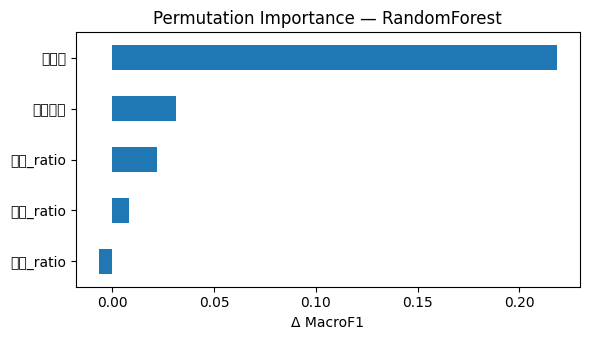

In [ ]:
tr, te = outer_cv[0]
fitted = main_model.fit(X.iloc[tr], y.iloc[tr])
perm = permutation_importance(fitted, X.iloc[te], y.iloc[te], scoring='f1_macro',
                              n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print('[permutation importance]\n', perm_s.round(4).to_string())

main_model.fit(X, y)
inner_clf = main_model.named_steps['clf'] if isinstance(main_model, Pipeline) else main_model
if hasattr(inner_clf, 'feature_importances_'):
    native = pd.Series(inner_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
    print('\n[impurity importance]\n', native.round(3).to_string())

plt.figure(figsize=(6, 3.5))
perm_s.sort_values().plot.barh()
plt.title(f'Permutation Importance — {best_name}'); plt.xlabel('Δ MacroF1')
plt.tight_layout(); plt.savefig(f'{ARTIFACT_DIR}/feature_importance.png', dpi=150); plt.show()

## 11. 일반화 검증 — Ablation + Leave-One-Line-Out

**Pooled ablation**: 시간+방향만 쓴 모델 vs 토지이용 추가 모델을 비교해 토지이용의 순수 기여도를 측정.

**Leave-One-Line-Out (LOLO)**: 7개 노선으로 학습 후 나머지 1개 노선으로 transfer 성능을 확인.
증분/효과가 ≈0 또는 음수면 → 정적 토지이용은 시간대 신호 위에 일반화 가능한 정보를 추가하지 못함을 의미.

In [ ]:
from sklearn.base import clone

def make_main():
    return clone(best_estimators[best_name])

gen = {}

# Pooled ablation
m0 = cross_val_predict(make_main(), X[['상하구분', '시간대']], y, cv=outer_cv, n_jobs=-1)
m1 = cross_val_predict(make_main(), X[FEATURES], y, cv=outer_cv, n_jobs=-1)
gen['ablation'] = {
    'time_only_f1': float(f1_score(y, m0, average='macro')),
    'plus_land_f1': float(f1_score(y, m1, average='macro')),
}
gen['ablation']['land_increment'] = gen['ablation']['plus_land_f1'] - gen['ablation']['time_only_f1']
print(f"[ablation] 시간+방향 {gen['ablation']['time_only_f1']:.3f} → +토지 {gen['ablation']['plus_land_f1']:.3f} "
      f"| 증분 {gen['ablation']['land_increment']:+.3f}")

# Leave-One-Line-Out
lolo = []
for tl in LINES:
    trd, ted = df[df['호선'] != tl], df[df['호선'] == tl]
    if len(trd) == 0 or len(ted) == 0:
        continue
    a = make_main().fit(trd[['상하구분', '시간대']], trd['혼잡도_등급'])
    b = make_main().fit(trd[FEATURES], trd['혼잡도_등급'])
    f1t = f1_score(ted['혼잡도_등급'], a.predict(ted[['상하구분', '시간대']]), average='macro')
    f1f = f1_score(ted['혼잡도_등급'], b.predict(ted[FEATURES]), average='macro')
    lolo.append({'line': tl, 'n': int(len(ted)), 'time_only': float(f1t),
                 'plus_land': float(f1f), 'land_effect': float(f1f - f1t)})
    print(f'  LOLO {str(tl):6s} (n={len(ted):4d}) | 시간 {f1t:.3f} | +토지 {f1f:.3f} | 효과 {f1f-f1t:+.3f}')

gen['lolo'] = lolo
gen['lolo_mean_land_effect'] = float(np.mean([r['land_effect'] for r in lolo])) if lolo else None
print(f"\n[LOLO] 토지 효과 평균 {gen['lolo_mean_land_effect']:+.3f}")

[ablation] 시간+방향 0.435 → +토지 0.457 | 증분 +0.022
  LOLO test=2호선    (n=2040) | 시간 0.408 | +토지 0.421 | 효과 +0.014
  LOLO test=5호선    (n=2040) | 시간 0.419 | +토지 0.389 | 효과 -0.030
  LOLO test=6호선    (n=1460) | 시간 0.346 | +토지 0.362 | 효과 +0.016
  LOLO test=7호선    (n=1480) | 시간 0.437 | +토지 0.410 | 효과 -0.027
  LOLO test=3호선    (n=1280) | 시간 0.411 | +토지 0.369 | 효과 -0.043
  LOLO test=4호선    (n= 960) | 시간 0.397 | +토지 0.474 | 효과 +0.076
  LOLO test=8호선    (n= 440) | 시간 0.456 | +토지 0.344 | 효과 -0.112
  LOLO test=1호선    (n= 360) | 시간 0.509 | +토지 0.489 | 효과 -0.019
[LOLO] 토지효과 평균 -0.016


## 12. 아티팩트 저장

In [ ]:
joblib.dump(main_model, f'{ARTIFACT_DIR}/best_model_{best_name}.joblib')
sta.to_csv(f'{ARTIFACT_DIR}/station_landuse_ratio.csv', index=False, encoding='utf-8-sig')
with open(f'{ARTIFACT_DIR}/metrics.json', 'w', encoding='utf-8') as f:
    json.dump({
        'config': {
            'catchment_radius_m': CATCHMENT_R, 'n_classes': N_CLASSES,
            'outer_splits': OUTER_SPLITS, 'inner_splits': INNER_SPLITS,
            'weekday_only': WEEKDAY_ONLY, 'lines': LINES,
            'features': FEATURES, 'random_state': RANDOM_STATE,
        },
        'model_comparison_nested': {
            k: {m: results[k][m] for m in ['nested_macro_f1', 'nested_accuracy', 'nested_mae']}
            for k in results
        },
        'best_model':             best_name,
        'best_params':            best_params,
        'final_evaluation':       eval_metrics,
        'permutation_importance': perm_s.round(5).to_dict(),
        'generalization':         gen,
    }, f, ensure_ascii=False, indent=2)
print(f'[save] → {ARTIFACT_DIR}/')

[save] artifacts → ./artifacts/  (metrics.json, best_model, figures, ratio table)


## 13. 결과 요약

In [ ]:
print('=' * 70)
print(f'메인 모델: {best_name} | nested MacroF1 {results[best_name]["nested_macro_f1"]:.3f}')
print(f'토지 증분(pooled ablation): {gen["ablation"]["land_increment"]:+.3f}')
print(f'토지 효과(LOLO 평균):       {gen["lolo_mean_land_effect"]:+.3f}')
print('증분/효과가 ≈0 또는 음수 → 정적 토지이용은 시간대 신호 위에 일반화 가능한 정보를 추가하지 못함')
print('=' * 70)


메인 모델: RandomForest | nested MacroF1 0.450
토지 증분(pooled): +0.022 | LOLO 토지효과: -0.016
해석: 증분/transfer 가 ≈0/음수면 → 정적 토지신호는 시간 효과 위에
      일반화 정보를 더하지 못함 = cold-start 정보 천장. (양수면 토지신호 일반성 입증)


In [ ]:
# Colab 셀에서 실행 → artifacts 폴더를 zip으로 다운로드
import shutil
from google.colab import files
shutil.make_archive('artifacts', 'zip', 'artifacts')
files.download('artifacts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>